In [1]:
!pip install kagglehub

In [2]:
import kagglehub

path = kagglehub.dataset_download(
    "gunavenkatdoddi/eye-diseases-classification"
)

DATASET_PATH = path
print("Path to dataset files:", DATASET_PATH)

Using Colab cache for faster access to the 'eye-diseases-classification' dataset.
Path to dataset files: /kaggle/input/eye-diseases-classification


In [3]:
import os
import cv2
import numpy as np
import tensorflow as tf

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 8
NUM_CLASSES = 4

In [5]:
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    merged = cv2.merge((cl, a, b))
    enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)
    return enhanced

In [6]:
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = apply_clahe(img)

    img = preprocess_input(img)

    return img

In [7]:
class RetinalDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_paths, labels, batch_size=8, augment=False):
        self.image_paths = image_paths
        self.labels = labels
        self.batch_size = batch_size
        self.augment = augment

    def __len__(self):
        return len(self.image_paths) // self.batch_size

    def __getitem__(self, idx):
        batch_x = self.image_paths[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_y = self.labels[idx*self.batch_size:(idx+1)*self.batch_size]

        X, y = [], []

        for path, label in zip(batch_x, batch_y):
            img = preprocess_image(path)

            if self.augment:
                if np.random.rand() > 0.5:
                    img = np.fliplr(img)
                if np.random.rand() > 0.5:
                    img = np.flipud(img)

            X.append(img)
            y.append(label)

        return np.array(X), np.array(y)

In [9]:
class_names = [
    "cataract",
    "diabetic_retinopathy",
    "glaucoma",
    "normal"
]

label_map = {cls: idx for idx, cls in enumerate(class_names)}

image_paths = []
labels = []

for cls in class_names:
    folder = os.path.join(DATASET_PATH, "dataset", cls)
    print("Reading from:", folder)

    for img in os.listdir(folder):
        image_paths.append(os.path.join(folder, img))
        labels.append(label_map[cls])

labels = np.array(labels)

Reading from: /kaggle/input/eye-diseases-classification/dataset/cataract
Reading from: /kaggle/input/eye-diseases-classification/dataset/diabetic_retinopathy
Reading from: /kaggle/input/eye-diseases-classification/dataset/glaucoma
Reading from: /kaggle/input/eye-diseases-classification/dataset/normal


In [10]:
train_p, temp_p, train_l, temp_l = train_test_split(
    image_paths,
    labels,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

val_p, test_p, val_l, test_l = train_test_split(
    temp_p,
    temp_l,
    test_size=0.5,
    random_state=42,
    stratify=temp_l
)

train_l = to_categorical(train_l, NUM_CLASSES)
val_l = to_categorical(val_l, NUM_CLASSES)
test_l = to_categorical(test_l, NUM_CLASSES)

In [11]:
train_gen = RetinalDataGenerator(train_p, train_l, BATCH_SIZE, augment=True)
val_gen   = RetinalDataGenerator(val_p, val_l, BATCH_SIZE)
test_gen  = RetinalDataGenerator(test_p, test_l, BATCH_SIZE)

In [12]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 1,825,124 (6.96 MB)

 Non-trainable params: 2,553,411 (9.74 MB)

In [13]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 117s 207ms/step - accuracy: 0.7323 - loss: 0.7007 - val_accuracy: 0.9051 - val_loss: 0.2866
Epoch 2/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 37s 99ms/step - accuracy: 0.8614 - loss: 0.3896 - val_accuracy: 0.9256 - val_loss: 0.2119
Epoch 3/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 38s 103ms/step - accuracy: 0.8923 - loss: 0.2969 - val_accuracy: 0.9130 - val_loss: 0.2097
Epoch 4/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 37s 100ms/step - accuracy: 0.9035 - loss: 0.2563 - val_accuracy: 0.9335 - val_loss: 0.1817
Epoch 5/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 37s 100ms/step - accuracy: 0.9239 - loss: 0.2080 - val_accuracy: 0.9272 - val_loss: 0.1766
Epoch 6/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 36s 99ms/step - accuracy: 0.9341 - loss: 0.1766 - val_accuracy: 0.9288 - val_loss: 0.1728
Epoch 7/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 37s 101ms/step - accuracy: 0.9474 - loss: 0.1444 - val_accuracy: 0.9320 - val_loss: 0.1594
Epoch 8/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 38s 102ms/step - accuracy: 0.9511 - loss: 0.

In [14]:
test_loss, test_acc = model.evaluate(test_gen)
print("Test Accuracy:", test_acc)

79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 158ms/step - accuracy: 0.9320 - loss: 0.2169
Test Accuracy: 0.9319620132446289


79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step


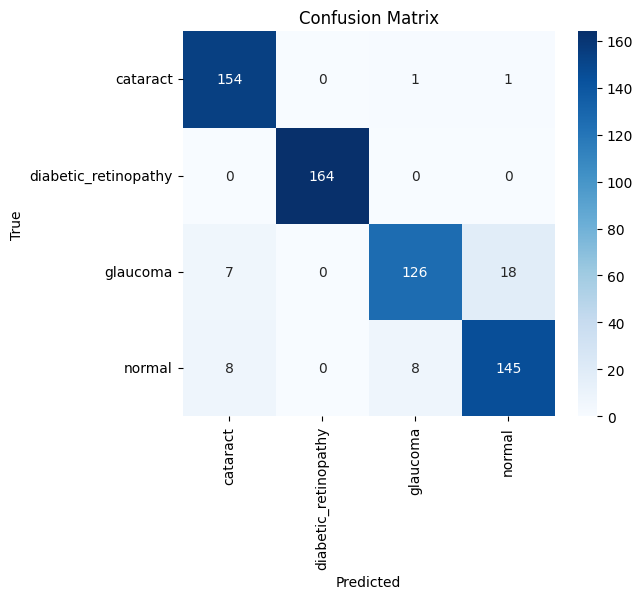


Classification Report:

                      precision    recall  f1-score   support

            cataract     0.9112    0.9872    0.9477       156
diabetic_retinopathy     1.0000    1.0000    1.0000       164
            glaucoma     0.9333    0.8344    0.8811       151
              normal     0.8841    0.9006    0.8923       161

            accuracy                         0.9320       632
           macro avg     0.9322    0.9306    0.9303       632
        weighted avg     0.9326    0.9320    0.9313       632



In [15]:
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true_full = np.argmax(test_l, axis=1)
y_true = y_true_full[:len(y_pred)]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("\nClassification Report:\n")
print(report)